In [10]:
import numpy as np
data = np.load("pi_bands_from_gpaw.npz")

dft_kpts = data["kpts"]        # shape (Nk, 2)
E_pi = data["energies"]    # shape (Nk, 4)
idx_pi = data["band_indices"]    # π band indices in DFT
EF = data["EF"]



In [14]:
import numpy as np
import plotly.graph_objects as go
from tb_bands import TBBandManager
from gpaw import GPAW, restart
atoms, calc = restart('DFT.gpw')
bands_manager = TBBandManager(atoms)
theta0 = np.array([
    3.1,  # gamma0
    0.39,  # gamma1
    0.315,  # gamma3
    0.044,  # gamma4
    0.0, 0.0, 0.0, 0.0  # epsA1, epsB1, epsA2, epsB2
])
# ======================================================
# 0. USER INPUTS (you MUST define these before running)
# ======================================================
# kpts_tb  = TB k-path: shape (N1, 2)
kpts_tb, label_positions, labels = bands_manager.build_kpath()
kpts_ase = dft_kpts
# kpts_ase = ASE k-path: shape (N2, 2)
# tb_bands = function that takes (Nk, 2) array of kpts
#            and returns energies shape (nbands, Nk)

# Example:
# E = tb_bands(kpts)   # returns (nbands, Nk)


# ======================================================
# 1. Build a 2D grid over kx, ky (same grid as your code)
# ======================================================
a0 = bands_manager.a0
Nk = 60
kx_vals = np.linspace(-2*np.pi/a0, 2*np.pi/a0, Nk)
ky_vals = np.linspace(-2*np.pi/a0, 2*np.pi/a0, Nk)
KX, KY = np.meshgrid(kx_vals, ky_vals)

# Flatten to shape (Nk^2, 2)
k_grid = np.c_[KX.ravel(), KY.ravel()]

# ======================================================
# 2. Compute TB bands on the grid using your tb_bands()
# ======================================================

Eall = bands_manager.tb_bands(k_grid, theta0)   # shape (nbands, Nk*Nk)
Nk2, nbands = Eall.shape             # Nk2 = Nk*Nk

bands = np.zeros((Nk, Nk, nbands))
for n in range(nbands):
    # take column n (all k-points for band n) and reshape
    bands[:, :, n] = Eall[:, n].reshape(Nk, Nk)


# ======================================================
# 3. Create interactive 3D Plotly figure
# ======================================================

fig = go.Figure()

# --- plot band surfaces ---
for n in range(nbands):
    fig.add_trace(go.Surface(
        x=KX, y=KY, z=bands[:,:,n],
        colorscale="Viridis",
        opacity=0.65,
        showscale=False,
        name=f"Band {n+1}"
    ))


# ======================================================
# 4. Add TB k-path (your manual path)
# ======================================================

# compute energies along TB path
E_tb_path = bands_manager.tb_bands(kpts_tb, theta0)   # shape (nbands, Nt)
# choose which band to plot (0 = lowest)
band_idx = 0
fig.add_trace(go.Scatter3d(
    x=kpts_tb[:,0],
    y=kpts_tb[:,1],
    z=E_tb_path[:, band_idx],          # pick one band
    mode='lines',
    line=dict(color='red', width=6),
    name='TB path'
))


# ======================================================
# 5. Add ASE k-path (after convert → cartesian)
# ======================================================

E_ase_path = bands_manager.tb_bands(kpts_ase, theta0)
fig.add_trace(go.Scatter3d(
    x=kpts_ase[:,0],
    y=kpts_ase[:,1],
    z=E_ase_path[:, band_idx],
    mode='lines',
    line=dict(color='blue', width=6),
    name='ASE path'
))


# ======================================================
# 6. Final layout
# ======================================================

fig.update_layout(
    title="3D Band Surfaces + TB & ASE k-Paths",
    scene=dict(
        xaxis_title="kx",
        yaxis_title="ky",
        zaxis_title="Energy (eV)",
        xaxis=dict(backgroundcolor="black"),
        yaxis=dict(backgroundcolor="black"),
        zaxis=dict(backgroundcolor="black"),
    ),
    width=950,
    height=800
)


# ======================================================
# 7. Save figure
# ======================================================

output_path = "../data/3d_bands.html"
fig.write_html(output_path)

output_path


'../data/3d_bands.html'

In [55]:
E_pi

array([[-2.1671976 ,  1.583743  , -2.5258661 ,  1.93712269],
       [-2.10064184,  1.57626517, -2.45868815,  1.91099727],
       [-1.90137716,  1.54165082, -2.25752653,  1.81801151],
       [-1.57072236,  1.44377422, -1.92358714,  1.61665776],
       [-1.11143465,  1.22790259, -1.45935308,  1.25084038],
       [-0.53099953,  0.68186907, -0.87128014,  0.84254097],
       [ 0.04060007,  0.04061875, -0.28892378,  0.38966272],
       [-0.49903449,  0.6565649 , -0.98617948,  0.98976624],
       [-1.28916884,  1.51723459, -1.89988443,  1.83793447],
       [-2.12982774,  2.47311605, -2.83505651,  2.78079935],
       [-2.96966969,  3.50949687, -3.74671425,  3.80220378],
       [-3.77353152,  4.61131374, -4.60525433,  4.88651907],
       [-4.51705201,  5.7585554 , -5.39062194,  6.01323378],
       [-5.1834605 ,  5.72690681, -5.97525601,  6.09305598],
       [-5.19545272,  5.0355499 , -5.21128042,  5.39570635],
       [-4.47860241,  4.46859231, -4.49203698,  4.8226655 ],
       [-3.86291758,  4.

In [54]:
E_tb_0

array([[-3.49672363e+00, -2.70373007e+00,  2.79172363e+00,
         3.40873007e+00],
       [-3.39647885e+00, -2.61573225e+00,  2.70104997e+00,
         3.31116113e+00],
       [-3.09886755e+00, -2.35449192e+00,  2.43186120e+00,
         3.02149827e+00],
       [-2.61324535e+00, -1.92826857e+00,  1.99264934e+00,
         2.54886458e+00],
       [-1.95538296e+00, -1.35105719e+00,  1.39777496e+00,
         1.90866519e+00],
       [-1.15027392e+00, -6.45540425e-01,  6.70317724e-01,
         1.12549662e+00],
       [-3.90000000e-01, -5.94537982e-16,  5.94510877e-16,
         3.90000000e-01],
       [-1.09462496e+00, -7.71501348e-01,  7.96223879e-01,
         1.06990243e+00],
       [-2.00883223e+00, -1.75564886e+00,  1.80781604e+00,
         1.95666505e+00],
       [-2.96089582e+00, -2.78018415e+00,  2.86052828e+00,
         2.88055170e+00],
       [-3.92095416e+00, -3.81323610e+00,  3.81229799e+00,
         3.92189227e+00],
       [-4.86304711e+00, -4.82692430e+00,  4.72664729e+00,
      

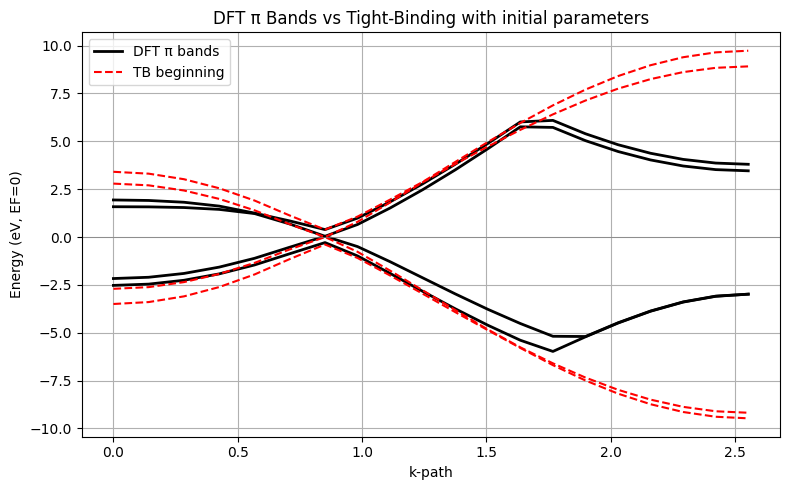

In [17]:
import matplotlib.pyplot as plt

kpts = kpts_ase
dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
E_tb_0 = bands_manager.tb_bands(kpts, theta0)


plt.figure(figsize=(8,5))

nb = E_pi.shape[1]

# DFT π bands
for i in range(nb):
    plt.plot(x, E_pi[:, i], 'k-', lw=2, label="DFT π bands" if i==0 else "")

# TB π bands
for i in range(4):
    plt.plot(x, E_tb_0[:, i], 'r--', lw=1.5, label="TB beginning" if i==0 else "")

plt.axhline(0, color='gray', lw=0.5)
plt.xlabel("k-path")
plt.ylabel("Energy (eV, EF=0)")
plt.title("DFT π Bands vs Tight-Binding with initial parameters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
E_tb_0

array([[-3.49672363e+00, -2.70373007e+00,  2.79172363e+00,
         3.40873007e+00],
       [-3.39647885e+00, -2.61573225e+00,  2.70104997e+00,
         3.31116113e+00],
       [-3.09886755e+00, -2.35449192e+00,  2.43186120e+00,
         3.02149827e+00],
       [-2.61324535e+00, -1.92826857e+00,  1.99264934e+00,
         2.54886458e+00],
       [-1.95538296e+00, -1.35105719e+00,  1.39777496e+00,
         1.90866519e+00],
       [-1.15027392e+00, -6.45540425e-01,  6.70317724e-01,
         1.12549662e+00],
       [-3.90000000e-01, -5.94537982e-16,  5.94510877e-16,
         3.90000000e-01],
       [-1.09462496e+00, -7.71501348e-01,  7.96223879e-01,
         1.06990243e+00],
       [-2.00883223e+00, -1.75564886e+00,  1.80781604e+00,
         1.95666505e+00],
       [-2.96089582e+00, -2.78018415e+00,  2.86052828e+00,
         2.88055170e+00],
       [-3.92095416e+00, -3.81323610e+00,  3.81229799e+00,
         3.92189227e+00],
       [-4.86304711e+00, -4.82692430e+00,  4.72664729e+00,
      

In [57]:
E_pi

array([[-2.1671976 ,  1.583743  , -2.5258661 ,  1.93712269],
       [-2.10064184,  1.57626517, -2.45868815,  1.91099727],
       [-1.90137716,  1.54165082, -2.25752653,  1.81801151],
       [-1.57072236,  1.44377422, -1.92358714,  1.61665776],
       [-1.11143465,  1.22790259, -1.45935308,  1.25084038],
       [-0.53099953,  0.68186907, -0.87128014,  0.84254097],
       [ 0.04060007,  0.04061875, -0.28892378,  0.38966272],
       [-0.49903449,  0.6565649 , -0.98617948,  0.98976624],
       [-1.28916884,  1.51723459, -1.89988443,  1.83793447],
       [-2.12982774,  2.47311605, -2.83505651,  2.78079935],
       [-2.96966969,  3.50949687, -3.74671425,  3.80220378],
       [-3.77353152,  4.61131374, -4.60525433,  4.88651907],
       [-4.51705201,  5.7585554 , -5.39062194,  6.01323378],
       [-5.1834605 ,  5.72690681, -5.97525601,  6.09305598],
       [-5.19545272,  5.0355499 , -5.21128042,  5.39570635],
       [-4.47860241,  4.46859231, -4.49203698,  4.8226655 ],
       [-3.86291758,  4.

In [59]:
# Must swap order of bands: E_pi and E_tb0 order does not match
E_pi = E_pi[:, [2, 0, 1, 3]]
E_pi

array([[-2.5258661 , -2.1671976 ,  1.583743  ,  1.93712269],
       [-2.45868815, -2.10064184,  1.57626517,  1.91099727],
       [-2.25752653, -1.90137716,  1.54165082,  1.81801151],
       [-1.92358714, -1.57072236,  1.44377422,  1.61665776],
       [-1.45935308, -1.11143465,  1.22790259,  1.25084038],
       [-0.87128014, -0.53099953,  0.68186907,  0.84254097],
       [-0.28892378,  0.04060007,  0.04061875,  0.38966272],
       [-0.98617948, -0.49903449,  0.6565649 ,  0.98976624],
       [-1.89988443, -1.28916884,  1.51723459,  1.83793447],
       [-2.83505651, -2.12982774,  2.47311605,  2.78079935],
       [-3.74671425, -2.96966969,  3.50949687,  3.80220378],
       [-4.60525433, -3.77353152,  4.61131374,  4.88651907],
       [-5.39062194, -4.51705201,  5.7585554 ,  6.01323378],
       [-5.97525601, -5.1834605 ,  5.72690681,  6.09305598],
       [-5.21128042, -5.19545272,  5.0355499 ,  5.39570635],
       [-4.49203698, -4.47860241,  4.46859231,  4.8226655 ],
       [-3.87446338, -3.

In [64]:
from scipy.optimize import least_squares

kpts = kpts_ase

cost_history = []
def cost_function(params, kpts, E_dft):
    """Return flatten residual vector (least_squares format)."""
    global cost_history

    E_tb = bands_manager.tb_bands(kpts, params)        # (Nk, 4)
    residual = (E_tb - E_dft).ravel()

    dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
    x = np.concatenate([[0], np.cumsum(dk)])
   # print('comparing ', E_tb[(0.7 < x) & (x < 0.9)], ' and ', E_dft[(0.7 < x) & (x < 0.9)])

    # Record cost = ||residual||^2
    cost = np.sum(residual**2)
    cost_history.append(cost)

    return residual

dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
res = least_squares(cost_function,
                    theta0,
                    args=(kpts[x < 1.75], E_pi[x<1.75]),
                    max_nfev=200,
                    verbose=2)

theta_fit = res.x
print("Fitted parameters:", theta_fit)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.9638e+00                                    2.26e+01    
       1              3         4.3690e+00      5.59e+00       7.85e-01       1.14e+00    
       2              4         4.0580e+00      3.11e-01       6.21e-01       8.22e-01    
       3              6         3.9931e+00      6.49e-02       1.44e-01       1.15e-01    
       4              8         3.9848e+00      8.27e-03       6.11e-02       4.89e-02    
       5              9         3.9839e+00      9.44e-04       1.11e-01       3.63e-02    
       6             10         3.9826e+00      1.31e-03       2.79e-02       1.49e-02    
       7             11         3.9824e+00      1.66e-04       3.60e-02       1.26e-02    
       8             12         3.9823e+00      5.79e-05       2.47e-02       9.10e-03    
       9             13         3.9823e+00      3.54e-05       1.81e-02       6.88e-03    

In [37]:
x<1.5

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False])

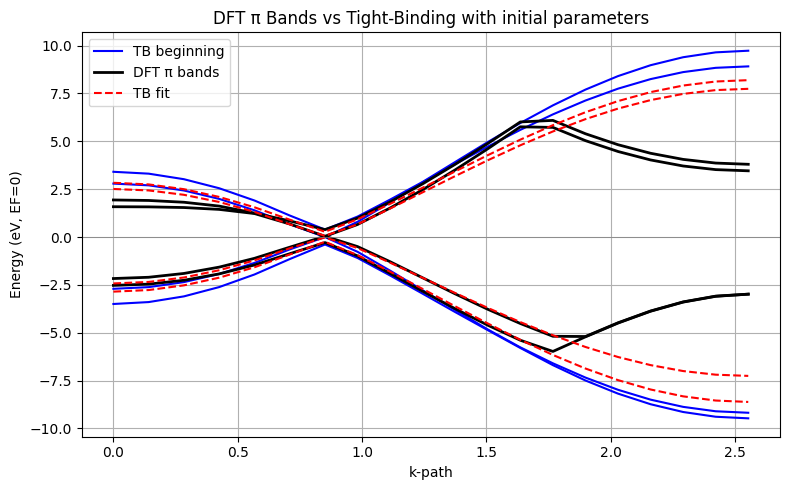

In [65]:
import matplotlib.pyplot as plt

kpts = kpts_ase
dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
E_tb_0 = bands_manager.tb_bands(kpts, theta0)
E_tb_fit = bands_manager.tb_bands(kpts, res.x)


plt.figure(figsize=(8,5))

nb = E_pi.shape[1]

for i in range(nb):
    plt.plot(x, E_tb_0[:, i], 'b-', lw=1.5, label="TB beginning" if i==0 else "")

# DFT π bands
for i in range(nb):
    plt.plot(x, E_pi[:, i], 'k-', lw=2, label="DFT π bands" if i==0 else "")

# TB π bands
for i in range(4):
    plt.plot(x, E_tb_fit[:, i], 'r--', lw=1.5, label="TB fit" if i==0 else "")

plt.axhline(0, color='gray', lw=0.5)
plt.xlabel("k-path")
plt.ylabel("Energy (eV, EF=0)")
plt.title("DFT π Bands vs Tight-Binding with initial parameters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [66]:
theta0, theta_fit

(array([3.1  , 0.39 , 0.315, 0.044, 0.   , 0.   , 0.   , 0.   ]),
 array([ 2.65015351,  0.17094938, -0.10215946,  0.14372453,  0.06197598,
         0.21192962, -0.18432997, -0.01808318]))